In [3]:
#Linrerias para datos 
import pandas as pd 
import numpy as np

#Librerias para graficos
import matplotlib as plt
import seaborn as sns

#Libreria para desdcargar datasets de kaggle
import kagglehub

#Libreria para trabajar con archivos y carpetas
from pathlib import Path
import shutil

# Configuración para que Pandas muestre todas las columnas
pd.set_option("display.max_columns", None)

In [6]:
path= kagglehub.dataset_download("mohankrishnathalla/startup-founder-burnout-and-failure-risk-dataset")
print("Ruta donde se descargó el dataset:", path)

100%|██████████| 1.81M/1.81M [00:00<00:00, 3.63MB/s]

Extracting files...
Ruta donde se descargó el dataset: C:\Users\User\.cache\kagglehub\datasets\mohankrishnathalla\startup-founder-burnout-and-failure-risk-dataset\versions\1


In [7]:
#Ver que archivos hay 
dataset_path= Path(path)

for file in dataset_path.glob("*"):  # * muestrame todo lo que hay
    print(file.name)

startup_founder_burnout_2026.csv


In [9]:
df= pd.read_csv(dataset_path/ "startup_founder_burnout_2026.csv")
df.head(5)

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Burnout_Level,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,6.2,6.5,15.2,3.4,4.2,2.2,2.6,1.0,Low,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,6.9,6.3,17.5,9.7,2.7,2.7,1.7,1.0,Low,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,4.0,5.4,4.8,5.7,5.6,7.7,9.0,5.8,Moderate,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,5.0,0.6,4.2,5.9,7.2,10.0,5.4,5.6,Moderate,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,5.2,2.5,9.2,5.4,5.6,6.5,3.4,4.6,Moderate,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


In [11]:
df.shape

(50000, 29)

In [12]:
df.columns

Index(['Founder_Type', 'Economic_Climate', 'Founder_Age',
       'Founder_Experience_Years', 'Industry', 'Funding_Stage', 'Work_Mode',
       'Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours',
       'Exercise_Days_Per_Week', 'Vacation_Days_Taken',
       'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score',
       'Decision_Fatigue_Score', 'Burnout_Score', 'Burnout_Level',
       'Founder_Burnout_Flag', 'Monthly_Revenue_Growth_Percent',
       'Runway_Months_Remaining', 'Product_Market_Fit_Score',
       'Employee_Turnover_Percent', 'Work_Life_Balance_Score',
       'Seeks_Mental_Health_Support', 'Shutdown_Probability', 'Shutdown_Risk',
       'Startup_Failure_Flag'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Type                    50000 non-null  str    
 1   Economic_Climate                50000 non-null  str    
 2   Founder_Age                     50000 non-null  int64  
 3   Founder_Experience_Years        50000 non-null  int64  
 4   Industry                        50000 non-null  str    
 5   Funding_Stage                   50000 non-null  str    
 6   Work_Mode                       50000 non-null  str    
 7   Team_Size                       50000 non-null  int64  
 8   Startup_Age_Months              50000 non-null  int64  
 9   Weekly_Work_Hours               50000 non-null  float64
 10  Sleep_Hours                     50000 non-null  float64
 11  Exercise_Days_Per_Week          50000 non-null  float64
 12  Vacation_Days_Taken             50000 non-n

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Founder_Age,50000.0,34.116580,6.503577,21.0,30.000,34.000,39.000,61.000
Founder_Experience_Years,50000.0,2.625380,2.102800,0.0,1.000,2.000,4.000,12.000
Team_Size,50000.0,54.708660,112.424631,1.0,6.000,16.000,54.000,799.000
Startup_Age_Months,50000.0,72.630640,41.044886,2.0,37.000,73.000,108.000,143.000
Weekly_Work_Hours,50000.0,63.703472,13.160604,28.0,54.700,63.600,72.600,110.000
Sleep_Hours,50000.0,5.690506,1.008238,2.8,5.000,5.700,6.400,9.000
Exercise_Days_Per_Week,50000.0,3.756374,1.298077,0.0,2.900,3.700,4.600,7.000
Vacation_Days_Taken,50000.0,9.256180,6.514507,0.0,4.100,8.900,13.700,35.000
Investor_Pressure_Score,50000.0,6.135680,2.223854,1.0,4.600,6.200,7.800,10.000
Cofounder_Conflict_Score,50000.0,4.012498,2.334365,0.0,2.300,4.000,5.600,10.000


In [18]:
# Identificar columnas categoricas y cuantos valores tiene
df.select_dtypes(include="object").nunique().sort_values()

C:\Users\User\AppData\Local\Temp\ipykernel_7636\2836994003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique().sort_values()


Seeks_Mental_Health_Support     2
Shutdown_Risk                   3
Work_Mode                       3
Burnout_Level                   3
Economic_Climate                4
Funding_Stage                   6
Founder_Type                    8
Industry                       10
dtype: int64

In [23]:
Categorical_cols= df.select_dtypes(include="object").columns

for col in Categorical_cols:
    print (f"\n{col} ({df[col].nunique()} valores:")
    print(df[col].unique())


Founder_Type (8 valores:
<StringArray>
[    'Serial Entrepreneur',           'Calm Operator',
     'Burned-Out Operator',       'Chaotic Innovator',
 'Growth Obsessed Founder',           'Visionary CEO',
       'Technical Builder',            'Solo Hustler']
Length: 8, dtype: str

Economic_Climate (4 valores:
<StringArray>
['Recession', 'Stable Economy', 'Bull Market', 'Funding Winter']
Length: 4, dtype: str

Industry (10 valores:
<StringArray>
[   'E-commerce',       'FinTech',   'ClimateTech',        'EdTech',
          'SaaS',            'AI',        'Gaming', 'Cybersecurity',
       'Biotech',    'HealthTech']
Length: 10, dtype: str

Funding_Stage (6 valores:
<StringArray>
['Seed', 'Bootstrapped', 'Series A', 'Pre-Seed', 'Series C', 'Series B']
Length: 6, dtype: str

Work_Mode (3 valores:
<StringArray>
['Remote', 'Hybrid', 'Office']
Length: 3, dtype: str

Burnout_Level (3 valores:
<StringArray>
['Low', 'Moderate', 'Severe']
Length: 3, dtype: str

Seeks_Mental_Health_Support (2 val

C:\Users\User\AppData\Local\Temp\ipykernel_7636\4201827398.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_cols= df.select_dtypes(include="object").columns


In [24]:
df["Startup_Failure_Flag"].value_counts()

Startup_Failure_Flag
0    38133
1    11867
Name: count, dtype: int64

In [25]:
df["Startup_Failure_Flag"].value_counts(normalize=True)*100

Startup_Failure_Flag
0    76.266
1    23.734
Name: proportion, dtype: float64

AttributeError: module 'matplotlib' has no attribute 'title'

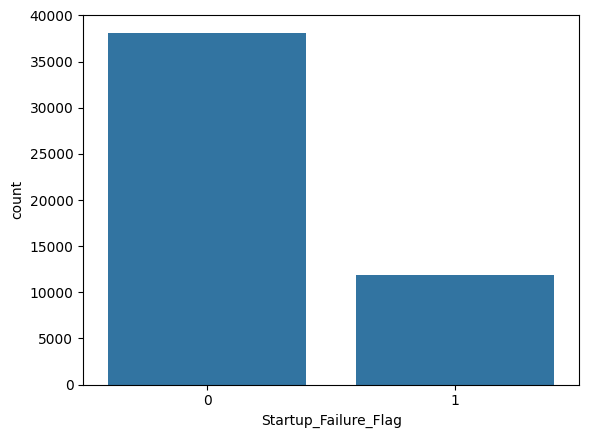

In [26]:
sns.countplot(data=df, x="Startup_Failure_Flag")
plt.title("Distribución de Startup_Failure_Flag")
plt.xlabel("Startup Failure Flag")
plt.ylabel("Cantidad")
plt.show()

In [33]:
group_means=df.groupby("Startup_Failure_Flag")[
    [
        "Stress_Score",
        "Burnout_Score",
        "Weekly_Work_Hours",
        "Sleep_Hours",
        "Runway_Months_Remaining",
        "Product_Market_Fit_Score",
        "Monthly_Revenue_Growth_Percent",
        "Employee_Turnover_Percent",
        "Work_Life_Balance_Score"
    ]
].mean()
print(group_means)

                      Stress_Score  Burnout_Score  Weekly_Work_Hours  \
Startup_Failure_Flag                                                   
0                         4.520436       2.809905          61.361091   
1                         7.022575       5.463099          71.230395   

                      Sleep_Hours  Runway_Months_Remaining  \
Startup_Failure_Flag                                         
0                        5.836603                13.744746   
1                        5.221042                 8.046035   

                      Product_Market_Fit_Score  \
Startup_Failure_Flag                             
0                                     5.850062   
1                                     3.661026   

                      Monthly_Revenue_Growth_Percent  \
Startup_Failure_Flag                                   
0                                           6.349705   
1                                           2.940035   

                      Employee_Turno

In [34]:
difference= group_means.loc[1]-group_means.loc[0]

difference.sort_values(ascending=False)

Employee_Turnover_Percent         17.424553
Weekly_Work_Hours                  9.869304
Burnout_Score                      2.653195
Stress_Score                       2.502139
Sleep_Hours                       -0.615562
Product_Market_Fit_Score          -2.189035
Work_Life_Balance_Score           -3.038402
Monthly_Revenue_Growth_Percent    -3.409670
Runway_Months_Remaining           -5.698711
dtype: float64

AttributeError: module 'matplotlib' has no attribute 'title'

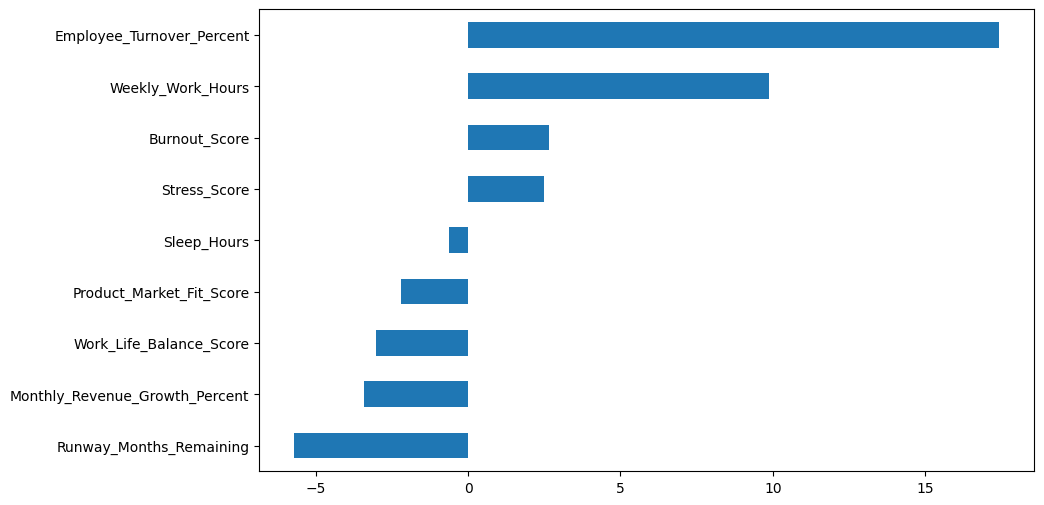

In [35]:
difference.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Diferencia promedio entre startups fallidas y no fallidas")
plt.xlabel("Diferencia promedio: fallo - no fallo")
plt.ylabel("Variable")
plt.show()

In [36]:
pd.crosstab(
    df["Shutdown_Risk"],
    df["Startup_Failure_Flag"],
    normalize="index"
) * 100

Startup_Failure_Flag,0,1
Shutdown_Risk,,
High,0.0,100.0
Low,100.0,0.0
Medium,100.0,0.0


In [37]:
df.groupby("Startup_Failure_Flag")["Shutdown_Probability"].describe()

,count,mean,std,min,25%,50%,75%,max
Startup_Failure_Flag,,,,,,,,
0,38133.0,0.250855,0.186900,0.00,0.085,0.209,0.398,0.650
1,11867.0,0.820948,0.097428,0.65,0.737,0.823,0.905,0.998


In [38]:
pd.crosstab(
    df["Burnout_Level"],
    df["Startup_Failure_Flag"],
    normalize="index"
) * 100

Startup_Failure_Flag,0,1
Burnout_Level,,
Low,92.093290,7.906710
Moderate,64.428203,35.571797
Severe,30.997405,69.002595


In [39]:
pd.crosstab(
    df["Funding_Stage"],
    df["Startup_Failure_Flag"],
    normalize="index"
) * 100

Startup_Failure_Flag,0,1
Funding_Stage,,
Bootstrapped,69.878570,30.121430
Pre-Seed,77.877947,22.122053
Seed,76.895655,23.104345
Series A,74.397681,25.602319
Series B,82.235529,17.764471
Series C,84.490923,15.509077


In [40]:
pd.crosstab(
    df["Economic_Climate"],
    df["Startup_Failure_Flag"],
    normalize="index"
) * 100

Startup_Failure_Flag,0,1
Economic_Climate,,
Bull Market,86.128961,13.871039
Funding Winter,64.153487,35.846513
Recession,54.320323,45.679677
Stable Economy,85.581727,14.418273


In [41]:
pd.crosstab(
    df["Work_Mode"],
    df["Startup_Failure_Flag"],
    normalize="index"
) * 100

Startup_Failure_Flag,0,1
Work_Mode,,
Hybrid,76.326714,23.673286
Office,76.632935,23.367065
Remote,76.087151,23.912849


In [42]:
pd.crosstab(
    df["Industry"],
    df["Startup_Failure_Flag"],
    normalize="index"
) * 100

Startup_Failure_Flag,0,1
Industry,,
AI,77.648105,22.351895
Biotech,76.645519,23.354481
ClimateTech,74.052591,25.947409
Cybersecurity,75.124502,24.875498
E-commerce,76.407864,23.592136
EdTech,75.288800,24.711200
FinTech,76.443378,23.556622
Gaming,76.992032,23.007968
HealthTech,76.202219,23.797781


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
raw_data_path = Path("../data/raw")
raw_data_path.mkdir(parents=True, exist_ok=True)

source_file = dataset_path / "startup_founder_burnout_2026.csv"
destination_file = raw_data_path / "startup_founder_burnout_2026.csv"

shutil.copy(source_file, destination_file)

print("Archivo copiado a:", destination_file)

Archivo copiado a: ..\data\raw\startup_founder_burnout_2026.csv


In [45]:
project_file = Path("../data/raw/startup_founder_burnout_2026.csv")

project_file.exists()

True

In [46]:
df = pd.read_csv("../data/raw/startup_founder_burnout_2026.csv")

df.head()

,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,Sleep_Hours,Exercise_Days_Per_Week,Vacation_Days_Taken,Investor_Pressure_Score,Cofounder_Conflict_Score,Stress_Score,Decision_Fatigue_Score,Burnout_Score,Burnout_Level,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,6.2,6.5,15.2,3.4,4.2,2.2,2.6,1.0,Low,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,6.9,6.3,17.5,9.7,2.7,2.7,1.7,1.0,Low,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,4.0,5.4,4.8,5.7,5.6,7.7,9.0,5.8,Moderate,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,5.0,0.6,4.2,5.9,7.2,10.0,5.4,5.6,Moderate,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,5.2,2.5,9.2,5.4,5.6,6.5,3.4,4.6,Moderate,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


In [49]:
target = "Startup_Failure_Flag"

columns_to_exclude = [
    "Startup_Failure_Flag",      # Variable objetivo
    "Shutdown_Probability",      # Fuga de información
    "Shutdown_Risk",             # Fuga de información
    "Burnout_Level",             # Derivada del Burnout_Score
    "Founder_Burnout_Flag"       # Derivada del Burnout_Score
]

features = [col for col in df.columns if col not in columns_to_exclude]

print("Variable objetivo:", target)
print("Columnas excluidas:", columns_to_exclude)
print("Cantidad de variables predictoras:", len(features))

features

Variable objetivo: Startup_Failure_Flag
Columnas excluidas: ['Startup_Failure_Flag', 'Shutdown_Probability', 'Shutdown_Risk', 'Burnout_Level', 'Founder_Burnout_Flag']
Cantidad de variables predictoras: 24


['Founder_Type',
 'Economic_Climate',
 'Founder_Age',
 'Founder_Experience_Years',
 'Industry',
 'Funding_Stage',
 'Work_Mode',
 'Team_Size',
 'Startup_Age_Months',
 'Weekly_Work_Hours',
 'Sleep_Hours',
 'Exercise_Days_Per_Week',
 'Vacation_Days_Taken',
 'Investor_Pressure_Score',
 'Cofounder_Conflict_Score',
 'Stress_Score',
 'Decision_Fatigue_Score',
 'Burnout_Score',
 'Monthly_Revenue_Growth_Percent',
 'Runway_Months_Remaining',
 'Product_Market_Fit_Score',
 'Employee_Turnover_Percent',
 'Work_Life_Balance_Score',
 'Seeks_Mental_Health_Support']

In [50]:
X = df[features]
y = df[target]

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (50000, 24)
Tamaño de y: (50000,)


In [51]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", len(numeric_features))
print(numeric_features)

print("\nVariables categóricas:", len(categorical_features))
print(categorical_features)

Variables numéricas: 18
['Founder_Age', 'Founder_Experience_Years', 'Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week', 'Vacation_Days_Taken', 'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score', 'Decision_Fatigue_Score', 'Burnout_Score', 'Monthly_Revenue_Growth_Percent', 'Runway_Months_Remaining', 'Product_Market_Fit_Score', 'Employee_Turnover_Percent', 'Work_Life_Balance_Score']

Variables categóricas: 6
['Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage', 'Work_Mode', 'Seeks_Mental_Health_Support']


C:\Users\User\AppData\Local\Temp\ipykernel_7636\30455297.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000, 24)
X_test: (10000, 24)
y_train: (40000,)
y_test: (10000,)


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [55]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Founder_Type','Economic_Climate','Founder_Age',..., 'Employee_Turnover_Percent','Work_Life_Balance_Score', 'Seeks_Mental_Health_Support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [56]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8697


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      7627
           1       0.67      0.88      0.76      2373

    accuracy                           0.87     10000
   macro avg       0.82      0.87      0.84     10000
weighted avg       0.89      0.87      0.88     10000



In [59]:
confusion_matrix(y_test, y_pred)

array([[6605, 1022],
       [ 281, 2092]])

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

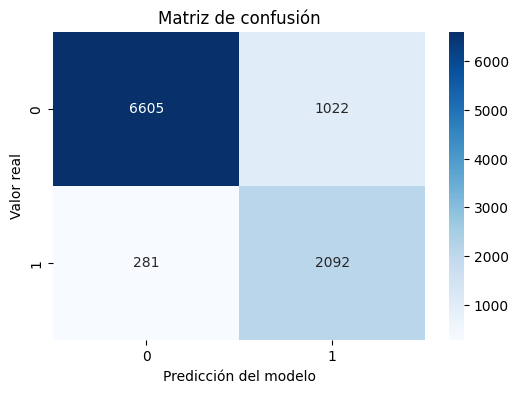

In [64]:

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

In [66]:
import joblib
from pathlib import Path

model_path = Path("models/startup_failure_model.pkl")

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_path)

print("Modelo guardado en:", model_path)

Modelo guardado en: models\startup_failure_model.pkl


In [67]:
loaded_model = joblib.load("models/startup_failure_model.pkl")

loaded_predictions = loaded_model.predict(X_test.head())

loaded_predictions

array([1, 0, 0, 0, 0])

In [68]:
y_proba = model.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.97876678, 0.14916645, 0.00149924, 0.13418342, 0.44929354,
       0.04418533, 0.95146743, 0.18737034, 0.45959992, 0.665699  ])

In [69]:
results = X_test.copy()

results["actual_failure"] = y_test.values
results["predicted_failure"] = y_pred
results["failure_probability"] = y_proba

results[["actual_failure", "predicted_failure", "failure_probability"]].head(10)

,actual_failure,predicted_failure,failure_probability
34347,1,1,0.978767
29263,0,0,0.149166
44208,0,0,0.001499
34709,1,0,0.134183
32491,0,0,0.449294
15565,0,0,0.044185
39665,1,1,0.951467
31644,0,0,0.187370
38551,0,0,0.459600
32579,0,1,0.665699


In [70]:
errors = results[results["actual_failure"] != results["predicted_failure"]]

errors[[
    "actual_failure",
    "predicted_failure",
    "failure_probability",
    "Stress_Score",
    "Burnout_Score",
    "Weekly_Work_Hours",
    "Runway_Months_Remaining",
    "Product_Market_Fit_Score",
    "Monthly_Revenue_Growth_Percent",
    "Employee_Turnover_Percent",
    "Work_Life_Balance_Score"
]].head(10)

,actual_failure,predicted_failure,failure_probability,Stress_Score,Burnout_Score,Weekly_Work_Hours,Runway_Months_Remaining,Product_Market_Fit_Score,Monthly_Revenue_Growth_Percent,Employee_Turnover_Percent,Work_Life_Balance_Score
34709,1,0,0.134183,7.2,4.9,72.2,17.6,2.4,10.7,33.9,4.9
32579,0,1,0.665699,6.0,5.9,51.2,12.2,4.4,20.9,68.0,5.7
27681,0,1,0.644238,5.5,3.3,76.8,7.5,3.3,10.8,51.7,5.7
19002,1,0,0.439237,7.8,3.8,88.8,11.5,3.3,36.8,38.8,5.8
36564,1,0,0.123566,8.6,6.5,74.0,18.9,7.4,9.7,56.5,2.1
18836,0,1,0.585594,6.2,3.6,70.3,9.1,1.9,-10.0,36.7,6.3
19025,0,1,0.732566,9.0,6.3,94.7,13.6,4.2,1.3,53.7,1.4
5273,0,1,0.892352,8.7,5.3,65.8,4.4,4.9,0.6,20.9,5.8
49039,0,1,0.900210,7.9,3.4,74.8,11.6,3.0,31.5,46.4,8.2
41625,0,1,0.593566,8.6,5.9,59.0,17.9,4.7,1.7,59.3,4.1


In [71]:
false_positives = results[
    (results["actual_failure"] == 0) & 
    (results["predicted_failure"] == 1)
]

false_negatives = results[
    (results["actual_failure"] == 1) & 
    (results["predicted_failure"] == 0)
]

print("Falsos positivos:", false_positives.shape[0])
print("Falsos negativos:", false_negatives.shape[0])

Falsos positivos: 1022
Falsos negativos: 281


In [72]:
error_analysis_features = [
    "Stress_Score",
    "Burnout_Score",
    "Weekly_Work_Hours",
    "Sleep_Hours",
    "Runway_Months_Remaining",
    "Product_Market_Fit_Score",
    "Monthly_Revenue_Growth_Percent",
    "Employee_Turnover_Percent",
    "Work_Life_Balance_Score"
]

correct_predictions = results[
    results["actual_failure"] == results["predicted_failure"]
]

summary_errors = pd.DataFrame({
    "Correct Predictions": correct_predictions[error_analysis_features].mean(),
    "False Positives": false_positives[error_analysis_features].mean(),
    "False Negatives": false_negatives[error_analysis_features].mean()
})

summary_errors

,Correct Predictions,False Positives,False Negatives
Stress_Score,4.927032,6.458806,5.487189
Burnout_Score,3.294469,4.702348,3.687189
Weekly_Work_Hours,62.956192,68.826517,65.690036
Sleep_Hours,5.739002,5.338943,5.517794
Runway_Months_Remaining,12.742773,9.313405,11.972954
Product_Market_Fit_Score,5.461642,4.168297,4.852669
Monthly_Revenue_Growth_Percent,5.676291,2.857926,4.860142
Employee_Turnover_Percent,34.693274,43.711350,38.501423
Work_Life_Balance_Score,6.930022,5.249706,6.398221


In [73]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values("abs_coefficient", ascending=False).head(15)

,feature,coefficient,abs_coefficient
14,num__Runway_Months_Remaining,-1.727943,1.727943
12,num__Burnout_Score,1.309469,1.309469
9,num__Cofounder_Conflict_Score,1.201179,1.201179
28,cat__Economic_Climate_Recession,1.182213,1.182213
29,cat__Economic_Climate_Stable Economy,-1.163872,1.163872
26,cat__Economic_Climate_Bull Market,-1.118613,1.118613
15,num__Product_Market_Fit_Score,-1.079019,1.079019
27,cat__Economic_Climate_Funding Winter,0.463802,0.463802
1,num__Founder_Experience_Years,-0.424493,0.424493
50,cat__Seeks_Mental_Health_Support_Yes,-0.344516,0.344516


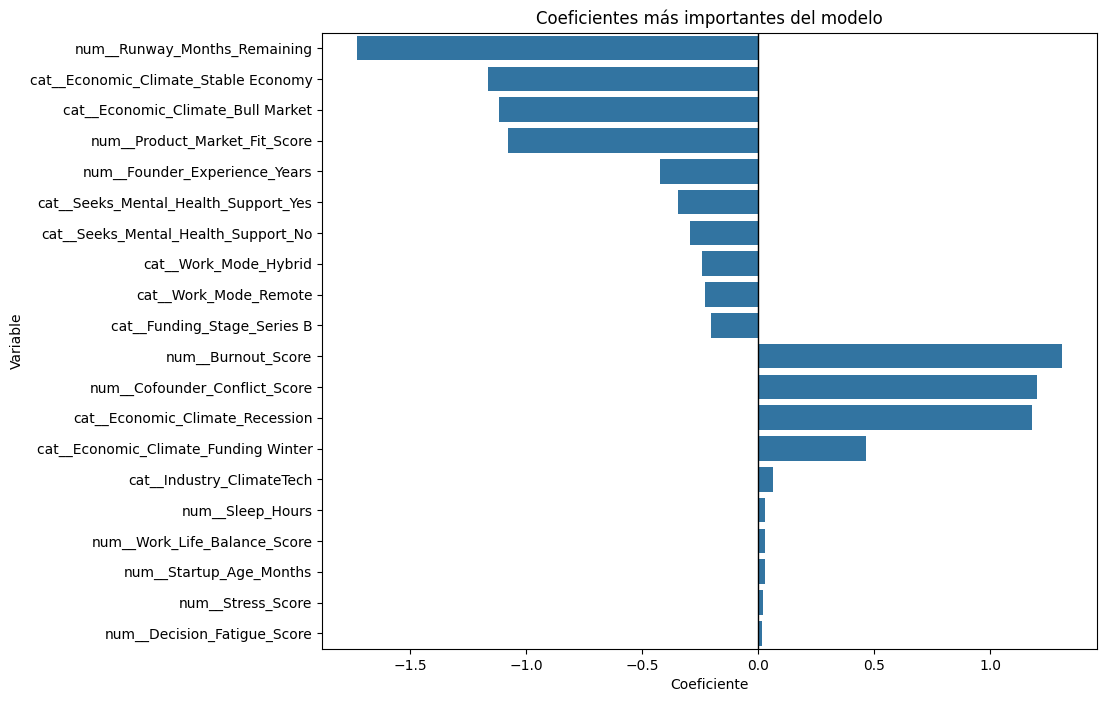

In [74]:
top_positive = coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)

top_coefficients = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_coefficients,
    x="coefficient",
    y="feature"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficientes más importantes del modelo")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

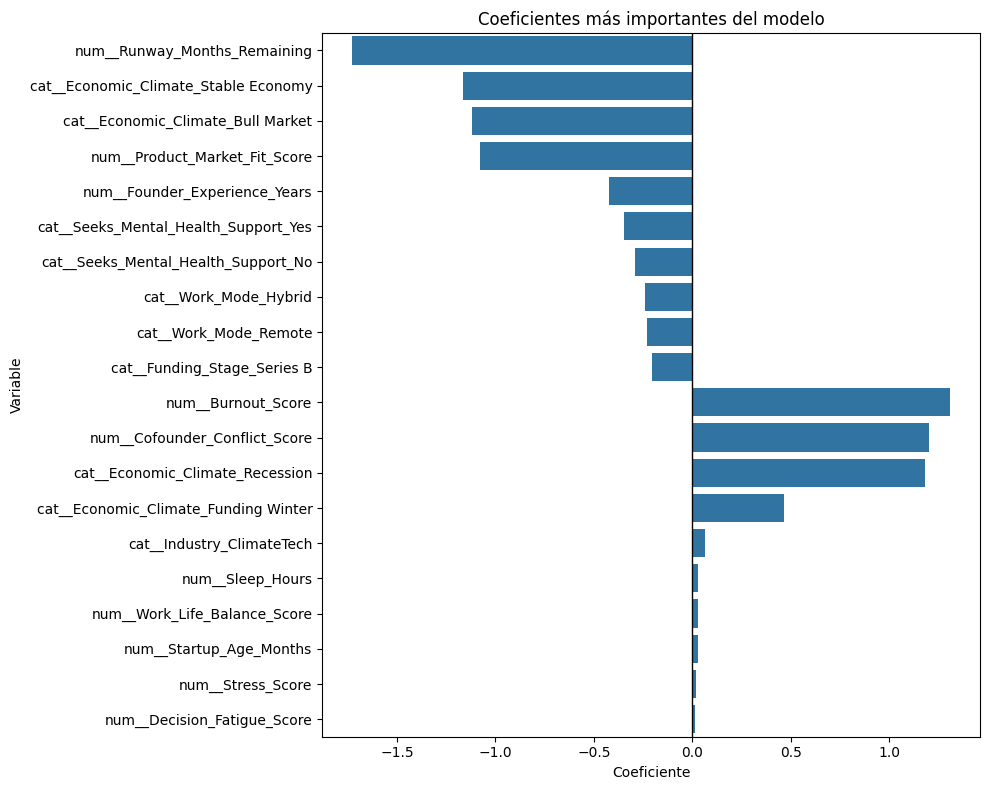

In [75]:
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_coefficients,
    x="coefficient",
    y="feature"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficientes más importantes del modelo")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig("reports/figures/model_coefficients.png", dpi=300)
plt.show()

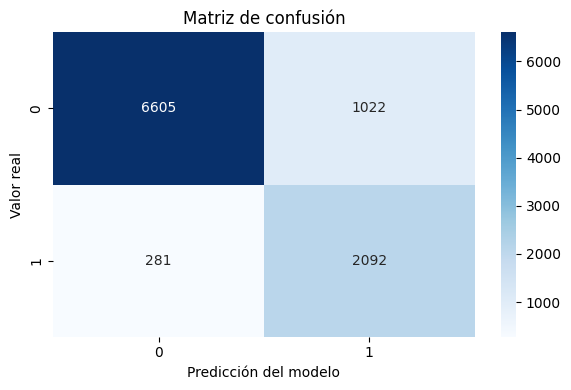

In [76]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.tight_layout()

plt.savefig("reports/figures/confusion_matrix.png", dpi=300)
plt.show()

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_class_1": precision_score(y_test, y_pred, pos_label=1),
    "recall_class_1": recall_score(y_test, y_pred, pos_label=1),
    "f1_class_1": f1_score(y_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("reports/model_metrics.csv", index=False)

metrics_df

,accuracy,precision_class_1,recall_class_1,f1_class_1
0,0.8697,0.671805,0.881584,0.76253
